In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

In [2]:
data = pd.read_pickle("../../../activdata/srg/tes/raw/FN/itr_200.bz2")
with open("umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)  # use pretrained model (fitted to FN itr_200 run 136)
# u = umap.UMAP() # redefine model

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


1. Fit the scaler as well as the reducer (u) (commented lines below) to a 'nice' timeseries with clear two different states.
2. Then comment out the fit lines, and use the fitting parameters to simply transform all new data (runs).
3. You should see the time segments getting nicely clustered into two states.
4. The time scale can be controlled using the chunk_size parameter. Smaller parameter value will detect states that last for shorter times. Larger values will require longer persistence within a state to be detected as distinct.

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


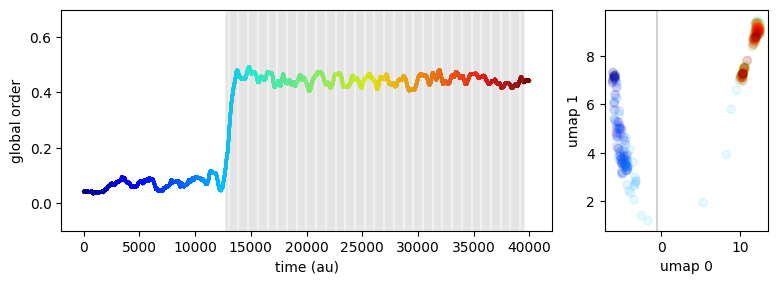

In [7]:
_data = (
    data[3].rolling(800, center=True).mean().ffill().bfill()
)  # fit to 39, borderline 135, 136, interesting 193
cmap = "jet"  # prism or jet

f, [ax0, ax2] = plt.subplots(
    1, 2, figsize=(8, 3), tight_layout=True, width_ratios=[3, 1]
)
ax0.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
ax0.set_ylim(-0.1, 0.7)
ax0.set_xlabel("time (au)")
ax0.set_ylabel("global order")

chunk_size = 400
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)

sep = -0.6

ax2.scatter(
    embedding[:, 0], embedding[:, 1], c=range(len(chunks)), alpha=0.1, cmap=cmap
)
ax2.set_xlabel("umap 0")
ax2.set_ylabel("umap 1")
ax2.axvline(sep, c="k", lw=0.25)

for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax0.axvline(l, c="gray", alpha=0.1)

plt.savefig("algo_fig.png")

In [21]:
# save trained model
with open("umap_model.pkl", "wb") as f:
    pickle.dump((_s, _u), f)